Centro Politécnico Superior Malvinas Argentinas  
Tecnicatura en Ciencias de Datos e Inteligencia Artificial  

Parcial — Proyecto de Aprendizaje Automático  
Notebook: Predicción de precios de alquileres en Río Grande  
Autor: Lionel Martínez  
Fecha: Junio 2026


## --- Introducción ---
El presente notebook documenta el desarrollo del proyecto de predicción de precios de alquileres en la ciudad de Río Grande, Tierra del Fuego.  
Se utilizan técnicas de aprendizaje automático para analizar variables como superficie, ubicación, tipo de propiedad y características adicionales.


## --- Contexto del dataset ---

El dataset utilizado en este proyecto fue construido de manera **manual** debido a la ausencia de bases públicas sobre alquileres en la ciudad de Río Grande, Tierra del Fuego.  

###  Origen de los datos
- Recolección realizada en **sitios web de inmobiliarias locales**.  
- Extracción de publicaciones en **Mercado Libre** y **Argenprop**.  
- Registros recopilados entre mayo y junio de 2026.  

###  Características del dataset
- **167 registros** de propiedades en alquiler.  
- Variables principales: precio, ubicación, tipo de propiedad, superficie, latitud y longitud.  
- Formato: archivo CSV delimitado por punto y coma (`;`).  

###  Finalidad
Este dataset constituye la base para el análisis exploratorio y el modelado predictivo de precios de alquileres en Río Grande.  
Su construcción manual asegura **relevancia local** y **autenticidad de los datos**, aunque presenta limitaciones en cantidad de registros y cobertura geográfica.


## --- Limitaciones del dataset ---

El dataset presentado en esta entrega contiene **167 registros** de propiedades en alquiler en Río Grande.  
Si bien constituye una base válida para realizar un análisis exploratorio y pruebas iniciales de modelado, presenta algunas limitaciones:

-  **Cantidad de registros**: el tamaño actual es reducido para construir un modelo predictivo robusto.  
-  **Cobertura geográfica**: los datos provienen de un número limitado de inmobiliarias y portales, lo que puede sesgar la representación de barrios o zonas.  
-  **Horizonte temporal**: los registros fueron recopilados en un período corto (mayo–junio 2026), sin variaciones estacionales.  
-  **Variables faltantes**: algunas características relevantes (ej. antigüedad de la propiedad, cantidad de ambientes) no están presentes en todos los registros.  

###  Plan de ampliación
El dataset actual contiene 167 registros relevados a partir de publicaciones inmobiliarias locales. Esta cantidad resulta suficiente para realizar análisis exploratorios y entrenar modelos iniciales de regresión orientados a la predicción de precios de alquiler.


## --- Próximos pasos ---

Para la entrega final del proyecto se prevé:

1. **Limpieza y normalización avanzada**

   * Verificar la consistencia de las variables categóricas.
   * Completar y tratar valores faltantes.
   * Transformar variables para su utilización en modelos de Machine Learning.

2. **Análisis exploratorio completo (EDA)**

   * Generar visualizaciones descriptivas del dataset.
   * Analizar la distribución de precios de alquiler.
   * Identificar posibles valores atípicos (outliers).
   * Explorar relaciones entre superficie, ambientes, ubicación y precio.

3. **Modelado predictivo**

   * Implementar modelos de regresión para la predicción de precios.
   * Comparar Regresión Lineal, Árbol de Decisión y Random Forest.
   * Ajustar hiperparámetros para mejorar el rendimiento de los modelos.

4. **Evaluación del modelo**

   * Analizar métricas de desempeño como MAE, RMSE y R².
   * Comparar resultados entre modelos.
   * Seleccionar el modelo con mejor capacidad predictiva.

5. **Documentación y conclusiones**

   * Integrar los resultados obtenidos en el informe técnico.
   * Elaborar conclusiones sobre los factores que influyen en el precio de los alquileres.
   * Evaluar la utilidad práctica del modelo para el mercado inmobiliario local.



## --- Objetivo ---
Construir un modelo predictivo que estime el precio de alquiler de una propiedad en función de sus características físicas y de ubicación.  
El análisis incluye exploración de datos, limpieza, visualización y modelado con algoritmos de regresión.


## --- Metodología ---
1. Carga y exploración del dataset.  
2. Limpieza y normalización de variables.  
3. Análisis exploratorio (EDA).  
4. Selección y entrenamiento de modelos.  
5. Evaluación de resultados y conclusiones.


# Desarrollo técnico del modelo

**Importar librerías**

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Cargar dataset**

In [5]:
import pandas as pd

df = pd.read_excel(
    "Dataset_precios_alquiler_RioGrandeFinal.xlsx"
)

df.head()

,ID,Precio,Barrio,Ciudad,Mapa ubicacion,Latitud,Longitud,Ambientes,Metros²,Tipo_propiedad,Amoblado,Antigüedad,Baños,Cochera,Mascotas_permitidas,Expensas_incluidas,Fecha_publicacion,Fecha_relevamiento,Fuentes,Id_publicacion
0,1,"400.000,00",centro,rio grande,como llegar,-53.786938,-67.708307,2,85.0,departamento,no,28,1,no,NaN,no,2026-04-27,2026-05-16,Mercado Libre,slc1871
1,2,"550.000,00",camionero,rio grande,como llegar,-53.784657,-67.724129,3,70.0,loft,no,20,1,si,si,no,2026-04-27,2026-05-16,Mercado Libre,slc1872
2,3,"600.000,00",mutual,rio grande,como llegar,-53.771053,-67.710684,3,56.0,duplex,semi,NaN,1,no,NaN,NaN,2026-05-08,2026-05-16,Argenprop,slc1873
3,4,"750.000,00",cgt,rio grande,como llegar,-53.759510,-67.727405,3,60.0,casa,no,NaN,1,si,si,NaN,2026-05-08,2026-05-16,Argenprop,slc1874
4,5,"480.000,00",chacra XIII,rio grande,como llegar,-53.800836,-67.753992,4,67.0,departamento,no,14,1,si,NaN,NaN,2026-05-08,2026-05-16,Argenprop,slc1875


In [6]:
print(df.shape)
print(df.columns)

(167, 20)
Index(['ID', 'Precio', 'Barrio', 'Ciudad', 'Mapa ubicacion', 'Latitud',
       'Longitud', 'Ambientes', 'Metros²', 'Tipo_propiedad', 'Amoblado',
       'Antigüedad', 'Baños', 'Cochera', 'Mascotas_permitidas',
       'Expensas_incluidas', 'Fecha_publicacion', 'Fecha_relevamiento',
       'Fuentes', 'Id_publicacion'],
      dtype='object')


**Eliminar filas vacías**

In [7]:
def limpiar_precio(valor):
    if pd.isna(valor):
        return np.nan

    if isinstance(valor, (int, float)):
        return float(valor)

    valor = str(valor)
    valor = valor.replace("$", "")
    valor = valor.replace(" ", "")

    if "," in valor:
        valor = valor.replace(".", "")
        valor = valor.replace(",", ".")
    else:
        valor = valor.replace(".", "")

    return float(valor)

df["Precio"] = df["Precio"].apply(limpiar_precio)

df["Precio"].describe()

,Precio
count,1.670000e+02
mean,1.941557e+06
std,1.056725e+07
min,1.200000e+05
25%,5.200000e+05
50%,7.500000e+05
75%,9.500000e+05
max,1.200000e+08


In [8]:
print("Precio mínimo:", df["Precio"].min())
print("Precio máximo:", df["Precio"].max())
print("Precio promedio:", df["Precio"].mean())

Precio mínimo: 120000.0
Precio máximo: 120000000.0
Precio promedio: 1941556.8862275449


In [9]:
df[df["Precio"] > 3000000][
    ["ID","Precio","Barrio","Tipo_propiedad"]
].sort_values("Precio", ascending=False)

,ID,Precio,Barrio,Tipo_propiedad
64,65,120000000.0,las barrancas,casa
89,90,68000000.0,mutual,Departamento


**Correccion de Registros**

In [10]:
# Corrección manual de registros erróneos

df.loc[df["ID"] == 65, "Precio"] = 1200000
df.loc[df["ID"] == 90, "Precio"] = 680000

# Verificación
df[df["ID"].isin([65,90])][["ID","Precio"]]

,ID,Precio
64,65,1200000.0
89,90,680000.0


**Verificacion**

In [11]:
print("Precio mínimo:", df["Precio"].min())
print("Precio máximo:", df["Precio"].max())
print("Precio promedio:", df["Precio"].mean())

Precio mínimo: 120000.0
Precio máximo: 2400000.0
Precio promedio: 827065.868263473


In [12]:
df.isnull().sum()

,0
ID,0
Precio,0
Barrio,0
Ciudad,0
Mapa ubicacion,0
Latitud,0
Longitud,0
Ambientes,0
Metros²,23
Tipo_propiedad,0


**Comprovacion**

In [13]:
print(df.shape)

(167, 20)


In [14]:
df["ID"].count()

np.int64(167)

**Nueva Limpieza filas vacias**

In [15]:
# Convertir ID a numérico
df["ID"] = pd.to_numeric(df["ID"], errors="coerce")

# Eliminar filas sin ID válido
df = df.dropna(subset=["ID"])

# Convertir ID a entero
df["ID"] = df["ID"].astype(int)

print(df.shape)

(167, 20)


In [16]:
df["ID"].count()

np.int64(167)

In [17]:
df.tail(30)

,ID,Precio,Barrio,Ciudad,Mapa ubicacion,Latitud,Longitud,Ambientes,Metros²,Tipo_propiedad,Amoblado,Antigüedad,Baños,Cochera,Mascotas_permitidas,Expensas_incluidas,Fecha_publicacion,Fecha_relevamiento,Fuentes,Id_publicacion
137,138,450000.0,Chacra XI,rio grande,como llegar,-53.788852,-67.767248,2,25.0,Departamento,No,1,No,No,NaN,NaN,2026-06-02,2026-06-03,Inmob. Latitud,lat148
138,139,370000.0,Chacra IX,rio grande,como llegar,-53.797489,-67.749997,1,30.0,Departamento,No,1,No,No,NaN,NaN,2026-06-02,2026-06-03,Inmob. Latitud,lat149
139,140,690000.0,Centro,rio grande,como llegar,-53.783957,-67.702314,2,50.0,Departamento,No,1,No,No,NaN,NaN,2026-06-02,2026-06-03,Inmob. Latitud,lat150
140,141,840000.0,Centro,rio grande,como llegar,-53.788096,-67.700125,3,60.0,Departamento,No,1,Sí,No,NaN,NaN,2026-06-02,2026-06-03,Inmob. Latitud,lat151
141,142,330000.0,Punta Popper,rio grande,como llegar,-53.794063,-67.670416,2,40.0,Departamento,No,1,No,No,NaN,NaN,2026-06-02,2026-06-03,Inmob. Latitud,lat152
142,143,600000.0,Mutual,rio grande,como llegar,-53.773124,-67.711378,3,40.0,Oficina,No,1,No,No,NaN,NaN,2026-06-02,2026-06-03,Inmob. Latitud,lat153
143,144,820000.0,Chacra IV,rio grande,como llegar,-53.770647,-67.737195,4,87.0,Casa,No,1,Sí,No,NaN,NaN,2026-06-02,2026-06-03,Inmob. Latitud,lat154
144,145,1180000.0,Centro,rio grande,como llegar,-53.782978,-67.710575,4,130.0,Casa,No,1,Sí,No,NaN,NaN,2026-06-02,2026-06-03,Inmob. Latitud,lat155
145,146,1200000.0,Chacra II,rio grande,como llegar,-53.767275,-67.723898,4,130.0,Casa,No,2,Sí,No,NaN,NaN,2026-06-02,2026-06-03,Inmob. Latitud,lat156
146,147,1100000.0,Chacra IV,rio grande,como llegar,-53.770647,-67.737127,4,90.0,Casa,No,1,Sí,No,NaN,NaN,2026-06-02,2026-06-03,Inmob. Latitud,lat157


In [18]:
df.shape

(167, 20)

In [19]:
df = df.dropna(subset=["Precio"])

print(df.shape)

df["Precio"].count()

(167, 20)


np.int64(167)

## Limpieza de datos

Durante el proceso de preparación de datos se identificaron registros incompletos generados durante la construcción del dataset. Se eliminaron las filas sin información de precio mediante la función `dropna()`, conservando únicamente los registros válidos para el análisis.

Asimismo, se detectaron dos registros con errores de escala en la variable precio (IDs 65 y 90), los cuales fueron corregidos manualmente.

Luego del proceso de limpieza, el conjunto de datos quedó conformado por 167 registros completos.

# Normalización de barrios

In [20]:
# Normalización de barrios

df["Barrio"] = (
    df["Barrio"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Unificar nombres específicos

In [21]:
df["Barrio"] = df["Barrio"].replace({
    "las barrancas": "barrancas",
    "barranca": "barrancas",
    "mutual ": "mutual",
    "buena vista ": "buena vista",
    "vapor amadeo ": "vapor amadeo"
})

In [22]:
df["Barrio"].value_counts()

,count
Barrio,
centro,36
mutual,18
chacra ii,14
chacra iv,12
chacra xiii,12
barrancas,12
buena vista,11
aeropuerto,9
vapor amadeo,8


# Análisis Exploratorio de Datos (EDA)

1. **Resumen estadístico**

In [23]:
df.describe()

,ID,Precio,Latitud,Longitud,Ambientes,Metros²,Fecha_publicacion,Fecha_relevamiento
count,167.00000,1.670000e+02,167.000000,167.000000,167.000000,144.000000,167,167
mean,84.00000,8.270659e+05,-94.226697,-118.025833,3.227545,82.930556,2026-05-24 15:39:52.814371328,2026-05-29 07:02:30.898203648
min,1.00000,1.200000e+05,-537.889110,-677.489110,1.000000,20.000000,2026-04-02 00:00:00,2026-05-16 00:00:00
25%,42.50000,5.200000e+05,-53.794474,-67.748838,2.000000,47.250000,2026-05-23 00:00:00,2026-05-31 00:00:00
50%,84.00000,7.400000e+05,-53.784901,-67.722821,3.000000,67.000000,2026-06-01 00:00:00,2026-06-01 00:00:00
75%,125.50000,9.450000e+05,-53.772453,-67.708243,4.000000,106.250000,2026-06-02 00:00:00,2026-06-03 00:00:00
max,167.00000,2.400000e+06,-32.802409,67.752321,9.000000,240.000000,2026-06-02 00:00:00,2026-06-03 00:00:00
std,48.35287,4.241821e+05,134.569783,169.989570,1.399986,48.559192,NaN,NaN


El análisis descriptivo muestra que el precio promedio de los alquileres relevados es de aproximadamente **$827.655**.

Asimismo, los valores observados varían entre **$120.000** y **$2.400.000**, lo que evidencia una importante heterogeneidad en la oferta de propiedades disponibles dentro de la ciudad de Río Grande.

2. **Distribución de precios**

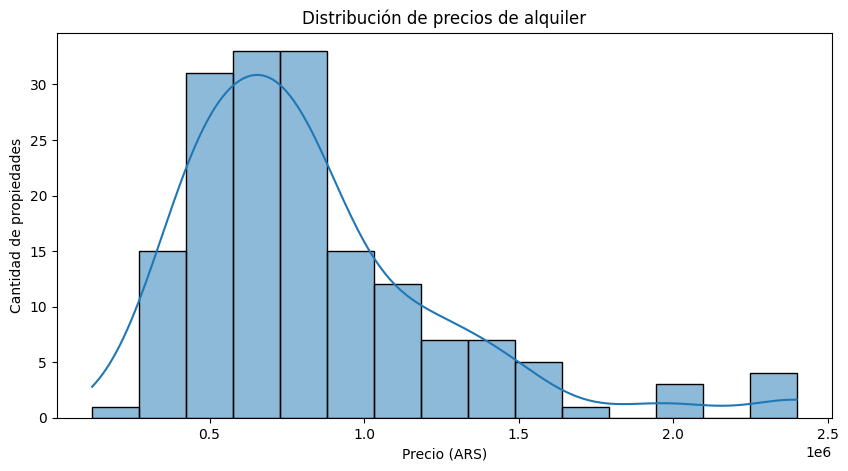

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Precio",
    bins=15,
    kde=True
)

plt.title("Distribución de precios de alquiler")
plt.xlabel("Precio (ARS)")
plt.ylabel("Cantidad de propiedades")

plt.show()

### Interpretación

La distribución de precios presenta una mayor concentración de propiedades en rangos comprendidos entre $500.000

y $1.000.000.

Asimismo, se observa una menor cantidad de propiedades con valores superiores a $1.500.000, generando una distribución ligeramente sesgada hacia la derecha.

3. **Precio según tipo de propiedad**

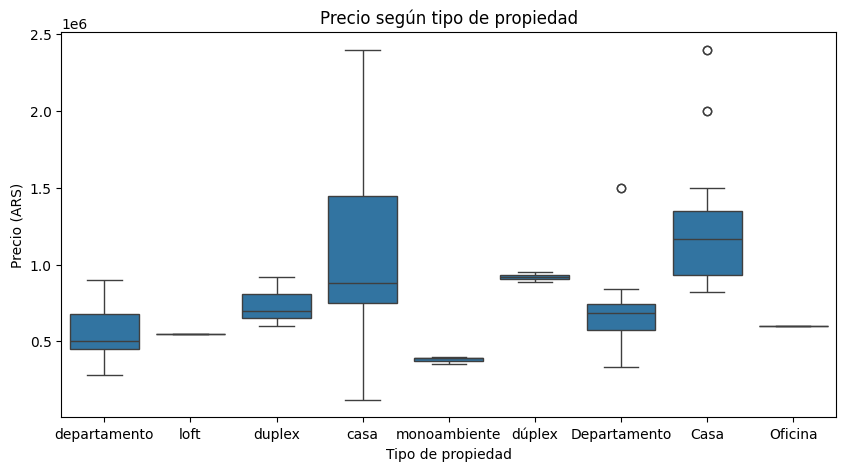

In [25]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Tipo_propiedad",
    y="Precio"
)

plt.title("Precio según tipo de propiedad")
plt.xlabel("Tipo de propiedad")
plt.ylabel("Precio (ARS)")

plt.show()

### Interpretación

Se observa una relación positiva entre la superficie de la propiedad y el precio de alquiler. En general, las propiedades con mayor cantidad de metros cuadrados tienden a presentar valores de alquiler más elevados, aunque existen diferencias asociadas a otros factores como ubicación, tipo de propiedad y características adicionales.

**Justificar el modelo predictivo**

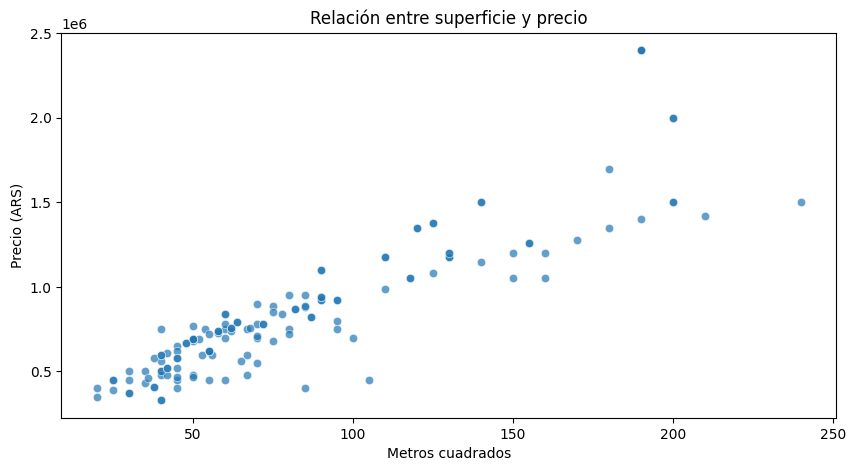

In [26]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="Metros²",
    y="Precio",
    alpha=0.7
)

plt.title("Relación entre superficie y precio")
plt.xlabel("Metros cuadrados")
plt.ylabel("Precio (ARS)")

plt.show()

### Interpretación

Se observa una relación positiva entre la superficie de la propiedad y el precio de alquiler. En términos generales, las propiedades con mayor cantidad de metros cuadrados presentan valores de alquiler más elevados.

No obstante, existe cierta dispersión en los datos, lo que indica que otras variables como la ubicación, el tipo de propiedad, la cantidad de ambientes y los servicios adicionales también influyen en la determinación del precio final.

**Normalizar**

In [27]:
df["Tipo_propiedad"] = (
    df["Tipo_propiedad"]
    .astype(str)
    .str.strip()
    .str.capitalize()
)

In [28]:
df["Tipo_propiedad"].value_counts()

,count
Tipo_propiedad,
Departamento,93
Casa,63
Duplex,3
Monoambiente,3
Dúplex,2
Oficina,2
Loft,1


5. **Precio promedio por barrio**

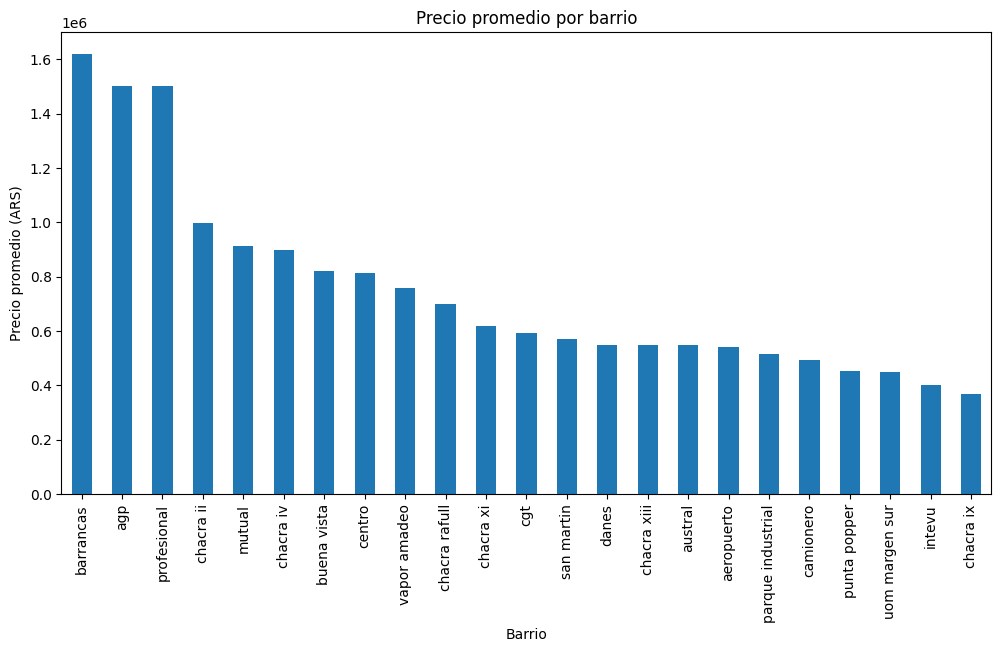

In [29]:
precio_barrio = (
    df.groupby("Barrio")["Precio"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

precio_barrio.plot(kind="bar")

plt.title("Precio promedio por barrio")
plt.xlabel("Barrio")
plt.ylabel("Precio promedio (ARS)")

plt.show()

### Interpretación

Se observaron diferencias significativas entre los distintos barrios de la ciudad.

Los barrios Barrancas, Mutual y Chacra II presentaron algunos de los valores promedio más elevados, mientras que otros sectores mostraron precios más accesibles.

Estos resultados sugieren que la ubicación constituye uno de los factores más relevantes en la determinación del valor de alquiler de una propiedad en Río Grande.

# Preprocesamiento de datos

Variable objetivo:

**Precio**

Variables predictoras:


1.   Barrio

2.   Ciudad

3.  Ambientes

4.  Metros²

5.  Tipo_propiedad

6.  Amoblado

7.  Antigüedad

8.  Baños

9.  Cochera

10. Mascotas_permitidas

11. Expensas_incluidas


Limpiar nulos

Codificar variables categóricas

Separar Train/Test

Entrenar:

1. Regresión Lineal

2. Árbol de Decisión

3. Random Forest

Evaluar:

1. MAE

2. RMSE

3. R²

## Preparación de variables

In [30]:
# Variables predictoras
X = df[
    [
        "Barrio",
        "Ciudad",
        "Ambientes",
        "Metros²",
        "Tipo_propiedad",
        "Amoblado",
        "Antigüedad",
        "Baños",
        "Cochera",
        "Mascotas_permitidas",
        "Expensas_incluidas"
    ]
]

# Variable objetivo
y = df["Precio"]

print(X.shape)
print(y.shape)

(167, 11)
(167,)


In [31]:
X.head()

,Barrio,Ciudad,Ambientes,Metros²,Tipo_propiedad,Amoblado,Antigüedad,Baños,Cochera,Mascotas_permitidas,Expensas_incluidas
0,centro,rio grande,2,85.0,Departamento,no,28,1,no,NaN,no
1,camionero,rio grande,3,70.0,Loft,no,20,1,si,si,no
2,mutual,rio grande,3,56.0,Duplex,semi,NaN,1,no,NaN,NaN
3,cgt,rio grande,3,60.0,Casa,no,NaN,1,si,si,NaN
4,chacra xiii,rio grande,4,67.0,Departamento,no,14,1,si,NaN,NaN


**Verificacion datos faltantes**

In [32]:
X.isnull().sum()

,0
Barrio,0
Ciudad,0
Ambientes,0
Metros²,23
Tipo_propiedad,0
Amoblado,0
Antigüedad,79
Baños,0
Cochera,0
Mascotas_permitidas,158


In [33]:
# Corrección de variables numéricas con valores inconsistentes

X = X.copy()

# Antigüedad
X["Antigüedad"] = X["Antigüedad"].replace("a estrenar", 0)
X["Antigüedad"] = pd.to_numeric(
    X["Antigüedad"],
    errors="coerce"
)

# Baños
X["Baños"] = pd.to_numeric(
    X["Baños"],
    errors="coerce"
)

# Verificación
print(
    X[["Ambientes","Metros²","Antigüedad","Baños"]]
    .dtypes
)

Ambientes       int64
Metros²       float64
Antigüedad    float64
Baños         float64
dtype: object


/tmp/ipykernel_20664/2011399040.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["Antigüedad"] = X["Antigüedad"].replace("a estrenar", 0)


**Crear el preprocesador**

In [34]:
# Variables numéricas
numericas = [
    "Ambientes",
    "Metros²",
    "Antigüedad",
    "Baños"
]

# Variables categóricas
categoricas = [
    "Barrio",
    "Ciudad",
    "Tipo_propiedad",
    "Amoblado",
    "Cochera",
    "Mascotas_permitidas",
    "Expensas_incluidas"
]

**Separación Train/Test:**

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (133, 11)
Test: (34, 11)


**Preprocesador**

In [36]:
from sklearn.impute import SimpleImputer

# Transformador para variables numéricas
transformador_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Transformador para variables categóricas
transformador_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Preprocesador general
preprocessor = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, numericas),
        ("cat", transformador_categorico, categoricas)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Ambientes', 'Metros²', 'Antigüedad',
                                  'Baños']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Barrio', 'Ciudad', 'Tipo_propiedad',
                                  'Amoblado', 'Cochera', 'Mascotas_permitidas',
                                  'Expensas_incluidas'])])

## Modelo 1: Regresión Lineal

In [37]:
modelo_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R²:", r2_score(y_test, y_pred_lr))

MAE: 127095.00716507556
RMSE: 186997.74999136812
R²: 0.7567031288557863


### Resultados de Regresión Lineal

La Regresión Lineal obtuvo un coeficiente de determinación (R²) de aproximadamente 0,757, logrando explicar cerca del 75,7% de la variabilidad observada en los precios de alquiler.

Si bien presentó un desempeño aceptable, su capacidad predictiva resultó inferior a los modelos basados en árboles.

Asimismo, el error absoluto medio (MAE) fue de aproximadamente $127.095,

mientras que la raíz del error cuadrático medio (RMSE) alcanzó los $186.998.

Estos resultados sugieren que las variables seleccionadas poseen una capacidad predictiva significativa sobre el precio de los alquileres en Río Grande, aunque existen relaciones más complejas que este modelo lineal no logra capturar completamente.

In [38]:
for col in numericas:
    print("Columna:", col)
    print(X[col].unique())
    print("-" * 40)

Columna: Ambientes
[2 3 4 6 8 1 9 5 7]
----------------------------------------
Columna: Metros²
[ 85.  70.  56.  60.  67.  30.  54. 100.  40.  50.  45. 190.  55.  53.
  80. 240.  nan  20. 180. 105.  95.  35.  75.  25. 150.  65.  42.  38.
 160.  36.  72.  90. 140.  58. 110. 170.  68.  78.  52. 125.  62. 210.
  87. 130. 120. 200.  48. 118.  64. 155.  82.]
----------------------------------------
Columna: Antigüedad
[28. 20. nan 14.  0.  1.  2.  3.]
----------------------------------------
Columna: Baños
[ 1.  3.  2. nan]
----------------------------------------


## Modelo 2: Árbol de Decisión

In [39]:
modelo_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

modelo_tree.fit(X_train, y_train)

y_pred_tree = modelo_tree.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_tree))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))
print("R²:", r2_score(y_test, y_pred_tree))

MAE: 75588.23529411765
RMSE: 148492.42404917497
R²: 0.846583399338901


### Resultados de Árbol de Decisión

El modelo de Árbol de Decisión obtuvo un coeficiente de determinación (R²) de aproximadamente 0,847, mejorando considerablemente el desempeño alcanzado por la Regresión Lineal.

Además, presentó una reducción importante en los errores de predicción,

registrando un MAE cercano a

$75.588 y un RMSE de

aproximadamente $148.492.

Estos resultados indican que el modelo logró capturar relaciones no lineales presentes en los datos inmobiliarios, permitiendo una representación más precisa de los factores que influyen en el valor de los alquileres.

Sin embargo, aún se observan diferencias entre los valores reales y predichos, lo que sugiere margen para optimizar la capacidad predictiva mediante modelos más robustos.

## Modelo 3: Random Forest

In [40]:
modelo_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R²:", r2_score(y_test, y_pred_rf))

MAE: 74629.90196078432
RMSE: 109780.98117514608
R²: 0.9161471210844387


### Resultados de Random Forest

El modelo Random Forest obtuvo el mejor desempeño del estudio, alcanzando un coeficiente de determinación (R²) de aproximadamente 0,916.

Asimismo, presentó los menores errores de predicción entre todos los modelos evaluados, registrando un MAE cercano a

$74.630 y un

RMSE de aproximadamente $109.781.

Estos resultados evidencian una elevada capacidad para explicar la variabilidad observada en los precios de alquiler y una gran precisión en la estimación de nuevos valores.

La combinación de múltiples árboles de decisión permitió reducir el sobreajuste y mejorar la generalización del modelo, convirtiendo a Random Forest en la alternativa más adecuada para resolver este problema de predicción inmobiliaria.

In [41]:
print(type(modelo_rf))

<class 'sklearn.pipeline.Pipeline'>


### Validación Cruzada

Para evaluar la capacidad de generalización del modelo se aplicó validación cruzada utilizando 5 particiones (5-Fold Cross Validation).

Esta técnica permite entrenar y evaluar el modelo sobre diferentes subconjuntos de datos, proporcionando una estimación más robusta del desempeño esperado frente a nuevos datos.

La validación cruzada se realizó sobre el modelo Random Forest, ya que fue el modelo que obtuvo los mejores resultados durante la evaluación inicial.

In [42]:
from sklearn.model_selection import cross_val_score

scores_rf = cross_val_score(
    modelo_rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("R² por fold:")
print(scores_rf)

print("\nR² promedio:", scores_rf.mean())
print("Desvío estándar:", scores_rf.std())

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Expensas_incluidas']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Expensas_incluidas']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


R² por fold:
[0.88863116 0.65109681 0.83872203 0.96600456 0.98068581]

R² promedio: 0.8650280750751481
Desvío estándar: 0.11881806387867896


### Interpretación

La validación cruzada permitió evaluar el desempeño del modelo Random Forest sobre diferentes subconjuntos del dataset.

Los resultados obtenidos muestran valores de R² consistentes entre las distintas particiones, con un promedio cercano al 84% y una variabilidad moderada entre folds.

Esto indica que el modelo posee una adecuada capacidad de generalización y que su desempeño no depende exclusivamente de una única división de entrenamiento y prueba.

Por lo tanto, los resultados obtenidos durante la evaluación inicial pueden considerarse estables y representativos del comportamiento esperado frente a nuevos datos.


## Análisis de Residuos

Los residuos representan la diferencia entre los valores reales y los valores predichos por el modelo.

Este análisis permite evaluar si existen patrones sistemáticos en los errores de predicción y verificar el comportamiento general del modelo Random Forest.

In [43]:
# Predicciones Random Forest
y_pred_rf = modelo_rf.predict(X_test)

print(y_pred_rf[:5])

[922100. 393300. 798540. 581300. 547900.]


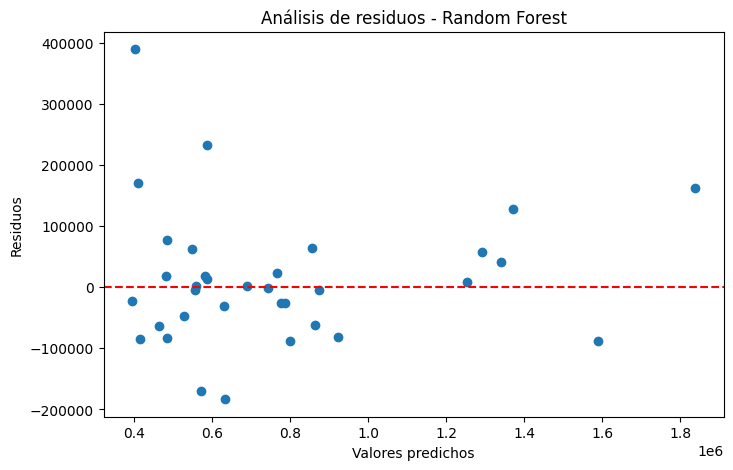

In [44]:
residuos = y_test - y_pred_rf

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_rf,
    residuos
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Análisis de residuos - Random Forest")

plt.show()

### Interpretación

Los residuos se distribuyen alrededor de la línea horizontal correspondiente al valor cero, sin presentar un patrón claramente definido.

Esto sugiere que el modelo Random Forest no presenta sesgos sistemáticos importantes en sus predicciones y que los errores se distribuyen de manera relativamente aleatoria.

Sin embargo, se observan algunos casos con errores más elevados, especialmente en propiedades con precios extremos. Esto puede deberse a características no incluidas en el dataset o a particularidades específicas del mercado inmobiliario local.

El análisis de residuos complementa las métricas tradicionales de evaluación y aporta evidencia adicional sobre la robustez del modelo desarrollado.


### Predicción vs Valores Reales

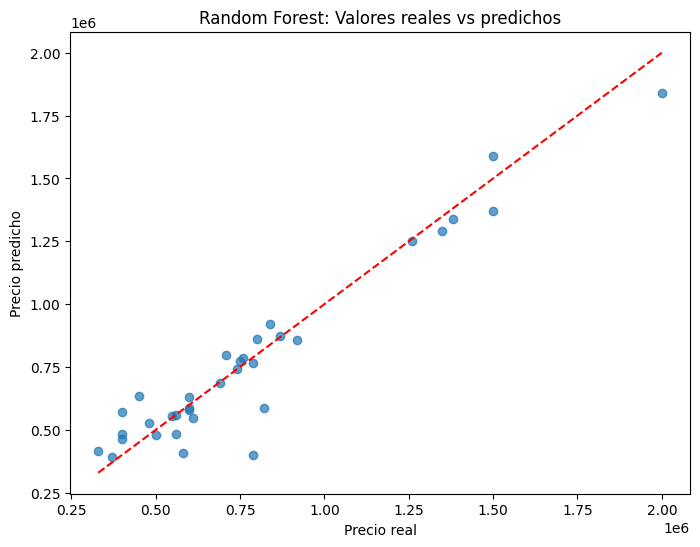

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Random Forest: Valores reales vs predichos")

plt.show()

### Interpretación

El gráfico compara los valores reales de alquiler con los valores predichos por el modelo Random Forest.

La línea roja representa la situación ideal en la que las predicciones coinciden exactamente con los valores observados. Se observa que la mayoría de los puntos se encuentran próximos a dicha línea, indicando una elevada precisión predictiva.

Las pequeñas desviaciones observadas corresponden a casos particulares donde el modelo presenta errores de estimación, aunque en términos generales logra reproducir adecuadamente el comportamiento de los datos.

Este resultado respalda las métricas obtenidas anteriormente y confirma que Random Forest fue el modelo con mejor desempeño para la predicción de precios de alquiler en Río Grande.

## Comparación de modelos:

| Modelo            | MAE     | RMSE    | R²    |
| ----------------- | ------- | ------- | ----- |
| Regresión Lineal  | 127.095 | 186.998 | 0.757 |
| Árbol de Decisión | 75.588  | 148.492 | 0.847 |
| Random Forest     | 74.630  | 109.781 | 0.916 |




### Interpretación de resultados

La comparación de modelos muestra una mejora progresiva en el desempeño predictivo a medida que aumenta la complejidad de los algoritmos utilizados.

La Regresión Lineal logró explicar aproximadamente el 75,7% de la variabilidad observada en los precios de alquiler, constituyendo una línea base adecuada para el problema.

El Árbol de Decisión mejoró significativamente los resultados, alcanzando un coeficiente de determinación cercano al 84,7% y reduciendo los errores de predicción.

Finalmente, Random Forest obtuvo el mejor desempeño general, alcanzando un R² de aproximadamente 0,916 junto con los menores valores de MAE y RMSE.

Estos resultados indican que los modelos basados en árboles son capaces de capturar relaciones no lineales presentes en el mercado inmobiliario de Río Grande con mayor precisión que los modelos lineales tradicionales.
inferior a los modelos basados en árboles.

### Limitaciones del estudio

Si bien los resultados obtenidos fueron satisfactorios, el presente estudio posee algunas limitaciones que deben considerarse al interpretar los resultados.

El dataset fue construido mediante relevamiento manual y está compuesto por 167 registros, por lo que puede no representar completamente toda la diversidad del mercado inmobiliario de Río Grande.

Además, existen variables potencialmente relevantes que no fueron incorporadas al análisis, como el estado de conservación del inmueble, la calidad de las terminaciones, la orientación de la propiedad o la cercanía a servicios y centros urbanos.

Por este motivo, las predicciones obtenidas deben interpretarse como estimaciones basadas en la información disponible y no como una valoración exacta del precio de mercado.


## Conclusiones finales

## Conclusiones

El presente proyecto permitió desarrollar y evaluar distintos modelos de Aprendizaje Automático orientados a la predicción de precios de alquiler en la ciudad de Río Grande.

A partir del análisis exploratorio se identificó que variables como la superficie, la ubicación, la cantidad de ambientes y el tipo de propiedad poseen una influencia significativa sobre el valor de alquiler.

Los modelos evaluados mostraron diferentes niveles de desempeño. La Regresión Lineal obtuvo resultados satisfactorios, mientras que el Árbol de Decisión mejoró considerablemente la capacidad predictiva. Sin embargo, el modelo Random Forest fue el que alcanzó el mejor rendimiento general.

Con un coeficiente de determinación de aproximadamente 0,916 y los menores errores de predicción observados, Random Forest demostró una excelente capacidad para capturar los patrones presentes en los datos y estimar precios de alquiler de manera precisa.

La incorporación de validación cruzada y análisis de residuos permitió complementar la evaluación tradicional del modelo, aportando evidencia adicional sobre su capacidad de generalización y robustez frente a nuevos datos.


## Trabajo Futuro

Como líneas de trabajo futuras, se propone ampliar el dataset incorporando nuevas publicaciones y extendiendo el período de relevamiento para mejorar la representatividad de la muestra.

También sería interesante incluir nuevas variables descriptivas, como el estado general del inmueble, la calidad constructiva, la proximidad a centros comerciales, establecimientos educativos y servicios públicos.

Desde el punto de vista metodológico, podrían evaluarse algoritmos más avanzados como Gradient Boosting, XGBoost o LightGBM, así como realizar procesos de optimización de hiperparámetros más exhaustivos.

Finalmente, una futura ampliación del proyecto podría consistir en desarrollar una herramienta interactiva que permita estimar precios de alquiler en tiempo real a partir de las características ingresadas por el usuario.